# Esame Laboratorio di Programmazione II - 13/01/2026


Scrivete chiaramente sul notebook il vostro nome e matricola e sul nome con cui salvate il file la vostra matricola.

Per ogni funzione e metodo che richiede un campionamento rispetto ad una distribuzione settate il seed a 0: ``np.random.seed(0)``.

Stampate il risultato delle domanda e consegnate il compito eseguito, quindi per cui ogni cella ha il corrispondente output.
Quindi ad esempio

e.g., 
NON scrivete: 
```python 
    lista=np.array([1,2,3])
```
ma 
```python
    lista=np.array([1,2,3]) 
    print('lista =', lista)   
```
Attenzione!Se scrivete:
```python
    lista=np.array([1,2,3])
    lista
```
``lista`` sarà l'unico ouput che si vede di quella cella

NB se l'output è una matrice molto grande non dovete stamparla.

Sarà valutata anche la presentazione, ad esempio un plot senza ettichette sugli assi o illleggibili sarà valutato meno bene di uno con ettichette chiare.

Commentate il compito di modo che si capisca cosa avete fatto.

Controllate attentamente di avere consegnato il file giusto.

In [1]:
#Potete importare direttamente qui le librerie che userete
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

## Esercizio 1
Un sensore ha registrato le seguenti temperature giornaliere (in °C) durante 12 giorni consecutivi:  
`18, 21, 19, 23, 25, 22, 20, 24, 26, 27, 21, 19`

1. Calcola la temperatura media del periodo.  
2. A causa di una ricalibrazione, tutte le temperature superiori a 22 °C devono essere aumentate di 1 °C. Aggiorna il vettore.  
3. Quanti giorni hanno registrato una temperatura pari o superiore a 25 °C dopo la ricalibrazione?


In [10]:
temperature = np.array([18, 21, 19, 23, 25, 22, 20, 24, 26, 27, 21, 19])
#1
media = np.mean(temperature)
print("Temperatura media: ", media)
#2
condizione = temperature>22
temperature[condizione] = temperature[condizione] +1
print("Nuove misure aggiornate: ", temperature)
#3
temp_sup = temperature >= 25
somma = np.sum(temp_sup)
print("Dopo la ricalibrazion hanno superato i 25 gradi : ", somma)

Temperatura media:  22.083333333333332
Nuove misure aggiornate:  [18 21 19 24 26 22 20 25 27 28 21 19]
Dopo la ricalibrazion hanno superato i 25 gradi :  4


## Esercizio 2

Un’urna contiene **3 palline rosse** e **2 palline blu**.  
Dopo ogni estrazione la pallina viene **rimessa nell’urna**.

1. Scrivi una funzione che simula **N estrazioni** e restituisce un array NumPy (`1 = rossa`, `0 = blu`).

2. Per valori di N pari a 50, 100, 150, …, 500:
   - ripeti la simulazione **100 volte**
   - calcola la **frequenza relativa media** delle palline rosse.

3. Rappresenta graficamente l’**andamento della frequenza relativa media delle palline rosse** in funzione del numero di estrazioni.


In [11]:
np.random.seed(0)
#1
def estrazioni(N):
    risultati = np.random.choice([1,0], size=N, p=(3/5,2/5))
    return risultati
#2
estraz_totale = estrazioni(100)
blocchi = np.arange(20,501,50)
freq_rel_rosse = []
for x in blocchi:
    estr_parz = estraz_totale[:x]
    somma_rosse = np.sum(estr_parz)
    freq_rel_rosse.append((somma_rosse)/x)
freq_rel_rosse

[np.float64(0.5),
 np.float64(0.5857142857142857),
 np.float64(0.5166666666666667),
 np.float64(0.36470588235294116),
 np.float64(0.2818181818181818),
 np.float64(0.22962962962962963),
 np.float64(0.19375),
 np.float64(0.16756756756756758),
 np.float64(0.14761904761904762),
 np.float64(0.13191489361702127)]

## Esercizio 3

1. Genera una matrice NumPy di dimensioni **6 x 8**, con valori estratti da una distribuzione normale con **media = 2** e **deviazione standard = 3**.

2. Per ogni riga, individua il valore **più vicino a zero** (cioè con valore assoluto minimo). Crea un array con questi **6 valori** (uno per riga).

3. Calcola quante righe hanno come valore più vicino a zero un numero **negativo**.


In [18]:
#1
np.random.seed(0)
matrice = np.random.normal(loc=2, scale=3, size=(6,8))
print(matrice)
#2
matrice_ass = np.abs(matrice)
matrice_ass
indc_min = np.argmin(matrice_ass, axis=1)
valori = matrice[np.arange(6), indc_min]
print("Array con 6 valori: \n", valori)
#3
vero_falso = valori<0
somma = np.sum(vero_falso)
print("N. valori minori di zero: ", somma)


[[ 7.29215704  3.20047163  4.93621395  8.7226796   7.60267397 -0.93183364
   4.85026525  1.54592838]
 [ 1.69034344  3.23179551  2.43213071  6.36282052  4.28311318  2.36502505
   3.3315897   3.00102298]
 [ 6.48223722  1.38452521  2.9392031  -0.56228722 -5.65896945  3.96085579
   4.5933086  -0.22649506]
 [ 8.80926387 -2.36309702  2.13727555  1.43844845  6.59833764  6.40807631
   2.46484228  3.13448756]
 [-0.66335724 -3.9423894   0.95626355  2.46904691  5.69087204  5.60713955
   0.83801955  1.09309175]
 [-1.1456589  -2.26005381 -3.11881057  7.85232619  0.47104345  0.6857771
  -1.75838608  4.33247107]]
Array con 6 valori: 
 [-0.93183364  1.69034344 -0.22649506  1.43844845 -0.66335724  0.47104345]
N. valori minori di zero:  3


In [19]:
# ===========================================================================
# (Setup) creazione dataset `students.csv` (da eseguire una sola volta)
# ===========================================================================

def make_students_csv(filename="students.csv", n=60, seed=42):
    """
    Dataset più "significativo":
    - exam_score cresce (non linearmente) con study_hours e attendance
    - presenza di cluster (studenti regolari / altalenanti / molto bravi)
    - qualche outlier (molte ore ma voto medio, poche ore ma voto alto)
    - qualche valore mancante
    """
    rng = np.random.default_rng(seed)

    student_id = np.arange(1, n + 1)

    group = rng.choice([0, 1, 2], size=n, p=[0.45, 0.40, 0.15])

    study_hours = np.empty(n, dtype=int)
    attendance = np.empty(n, dtype=float)

    idx0 = group == 0
    study_hours[idx0] = rng.integers(12, 28, size=idx0.sum())
    attendance[idx0] = rng.uniform(0.78, 1.00, size=idx0.sum())

    idx1 = group == 1
    study_hours[idx1] = rng.integers(5, 22, size=idx1.sum())
    attendance[idx1] = rng.uniform(0.60, 0.95, size=idx1.sum())

    idx2 = group == 2
    study_hours[idx2] = rng.integers(22, 45, size=idx2.sum())
    attendance[idx2] = rng.uniform(0.85, 1.00, size=idx2.sum())

    attendance = np.round(attendance, 2)

    noise = rng.normal(0, 6, size=n)
    nonlinear_bonus = 8 / (1 + np.exp(-(study_hours - 25) / 4))  # "curva a S"
    exam_score = 35 + 1.4 * study_hours + 22 * (attendance - 0.6) + nonlinear_bonus + noise
    exam_score = np.clip(exam_score, 35, 100)
    exam_score = np.round(exam_score).astype(float)

    for i in rng.choice(np.where(study_hours > 30)[0], size=min(2, np.sum(study_hours > 30)), replace=False):
        exam_score[i] = max(40, exam_score[i] - rng.integers(12, 20))

    for i in rng.choice(np.where(study_hours < 12)[0], size=min(2, np.sum(study_hours < 12)), replace=False):
        exam_score[i] = min(100, exam_score[i] + rng.integers(12, 20))

    p_pass = 1 / (1 + np.exp(-(exam_score - 62) / 6))
    passed = (rng.uniform(0, 1, size=n) < p_pass).astype(int)

    df = pd.DataFrame({
        "student_id": student_id,
        "exam_score": exam_score,
        "study_hours": study_hours,
        "attendance": attendance,
        "passed": passed
    })

    miss_att = rng.choice(df.index, size=max(1, n // 30), replace=False)
    miss_score = rng.choice(df.index.difference(miss_att), size=max(1, n // 30), replace=False)
    df.loc[miss_att, "attendance"] = np.nan
    df.loc[miss_score, "exam_score"] = np.nan

    df.to_csv(filename, index=False)
    return df

df = make_students_csv("students.csv", n=60, seed=0)
print(df.head())


   student_id  exam_score  study_hours  attendance  passed
0           1        68.0           11         NaN       1
1           2        70.0           21        0.99       0
2           3        74.0           18        0.89       1
3           4        82.0           27        0.87       1
4           5        67.0           18        0.85       1


## Esercizio 4

Utilizza il dataset `students.csv`, che contiene le seguenti colonne:  
`student_id`, `exam_score`, `study_hours`, `attendance`, `passed`  
(dove `passed` vale 1 se lo studente ha superato l’esame, 0 altrimenti).

1. Verifica la presenza di **valori mancanti per colonna** ed elimina le righe che ne contengono.

2. Crea una nuova colonna `performance_index` definita come:

   $$
   \texttt{performance\_index} = \texttt{exam\_score} \times \texttt{attendance}
   $$

3. Filtra gli studenti che hanno:
   - `study_hours` > 20  
   - `attendance` > 0.8  

4. Crea un **grafico a barre** con i **10 studenti con performance_index più alto**
   (usa `student_id` come etichetta).

5. Crea uno **scatter plot** con:
   - asse x = `study_hours`
   - asse y = `exam_score`
   - colore dei punti = `performance_index`

Valori mancanti per colonna: 
 student_id     0
exam_score     2
study_hours    0
attendance     2
passed         0
dtype: int64
Dataset filtrato : 
     student_id  exam_score  study_hours  attendance  passed  performance_index
1            2        70.0           21        0.99       0              69.30
3            4        82.0           27        0.87       1              71.34
5            6        75.0           32        0.93       1              69.75
9           10        94.0           31        0.94       1              88.36
12          13        82.0           33        0.98       1              80.36
13          14        90.0           27        1.00       1              90.00
16          17       100.0           40        0.87       1              87.00
18          19        72.0           21        0.88       1              63.36
19          20        75.0           21        0.95       1              71.25
20          21        73.0           26        0.89       1 

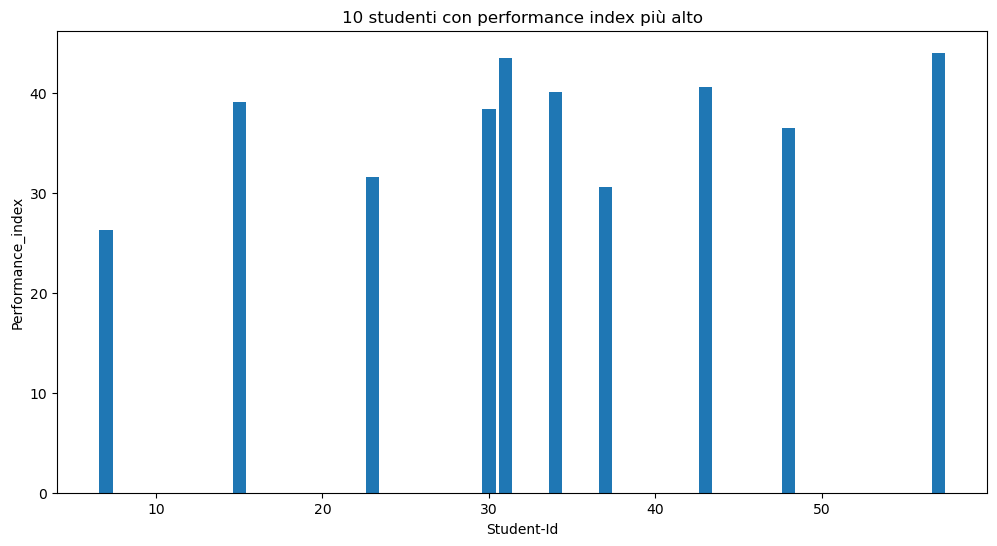

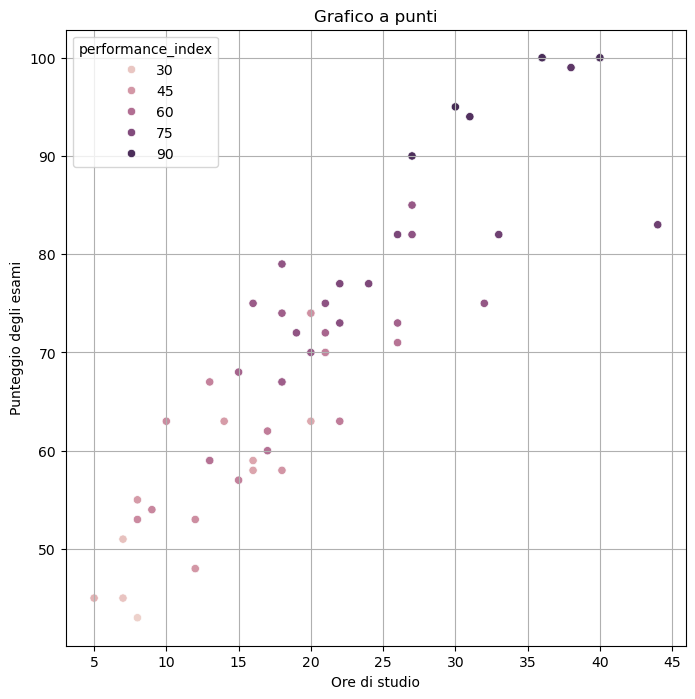

In [27]:
df = pd.read_csv("students.csv")
#1
val_manc = pd.isnull(df).sum()
print("Valori mancanti per colonna: \n", val_manc)
df = df.dropna()
#2
df["performance_index"] = df["exam_score"] * df["attendance"]
#3
filtraggio = df[(df["study_hours"] >20) & (df["attendance"]>0.8)]
print("Dataset filtrato : \n", filtraggio)
#4
df_ordinato = df.sort_values(by="performance_index").head(10)
plt.figure(figsize=(12,6))
plt.bar(df_ordinato["student_id"], df_ordinato["performance_index"])
plt.title("10 studenti con performance index più alto")
plt.xlabel("Student-Id")
plt.ylabel("Performance_index")
plt.show()
#5
plt.figure(figsize=(8,8))
sns.scatterplot(data = df, x="study_hours", y="exam_score", hue="performance_index")
plt.title("Grafico a punti")
plt.xlabel("Ore di studio")
plt.ylabel("Punteggio degli esami")
plt.grid(True)
plt.show()


## Esercizio 5

Utilizza lo stesso dataset `students.csv`.

1. Determina **numero di righe e colonne** del dataset ed elimina la colonna `passed`.

2. Trova il **valore di `exam_score` più frequente**.

3. Calcola la **media del punteggio d’esame (`exam_score`) per fasce di ore di studio**:
   - `0–10`
   - `11–20`
   - `21–30`
   - `>30`

4. Crea un **boxplot** dei valori di `exam_score` raggruppati per fascia di ore di studio.

5. Crea un **violin plot** della distribuzione di `attendance` per ciascuna fascia di ore di studio.


Numero di righe e colonne del dataset:  (60, 5)
Valore più frequente di exam_score:  63.0


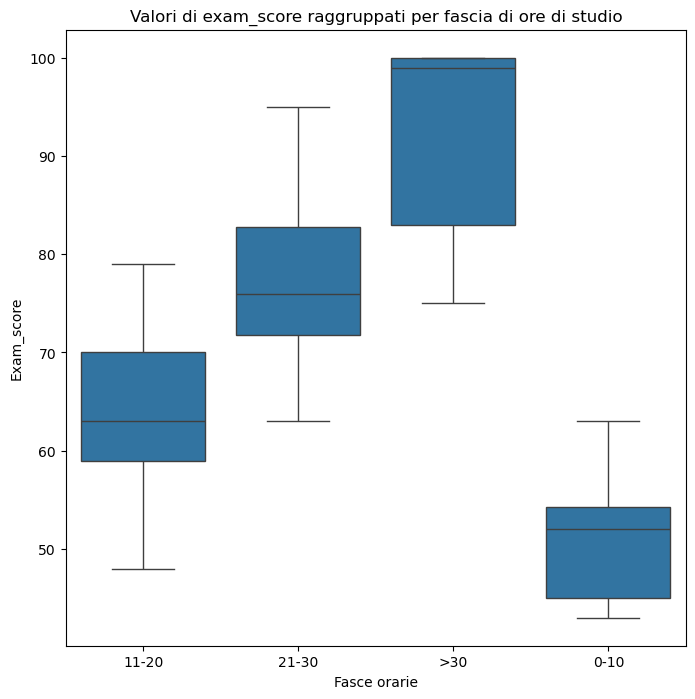

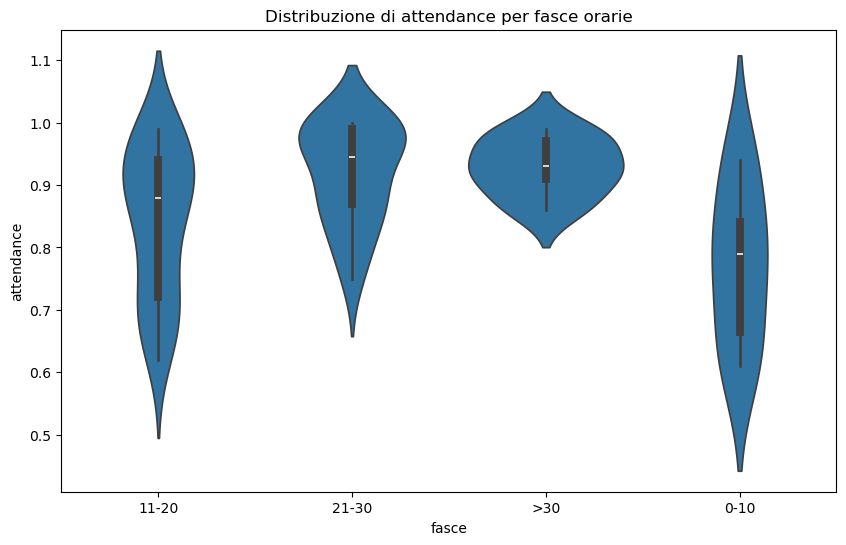

In [35]:
df = pd.read_csv("students.csv")
#1
dimensioni = df.shape
print("Numero di righe e colonne del dataset: ", dimensioni)
df = df.drop(columns="passed")
#2
val_freq = df["exam_score"].mode()[0]
print("Valore più frequente di exam_score: ", val_freq)
#3
fasce = []
for x in range(len(df)):
# Usiamo .iloc per accedere correttamente all'indice della riga
    hours = df["study_hours"].iloc[x] 
    if hours > 0 and hours <= 10:
        ticket = "0-10"
    elif hours >= 11 and hours <= 20:
        ticket = "11-20"
    elif hours >= 21 and hours <= 30:
        ticket = "21-30"
    else:
        ticket = ">30"
    fasce.append(ticket)
df["fasce"] = fasce
punteggio_esam = df.groupby("fasce")["exam_score"].mean()
#4
plt.figure(figsize=(8,8))
sns.boxplot(data = df, x="fasce", y="exam_score")
plt.title("Valori di exam_score raggruppati per fascia di ore di studio")
plt.xlabel("Fasce orarie")
plt.ylabel("Exam_score")
plt.show()
#5
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x= "fasce", y="attendance")
plt.title("Distribuzione di attendance per fasce orarie")
plt.show()

## Esercizio 6

Genera due array:

`x = np.linspace(0, 5, 80)`  
`y = 2.5 * x + 1.2 + np.random.normal(0, 0.5, 80)`

1. Usa `scipy.optimize.curve_fit` per stimare i parametri `a` e `b` della retta del tipo:

    $$
   y = a \cdot x + b
    $$

2. Plotta i punti originali e la retta ottenuta.

3. Calcola **MAE** (Mean Absolute Error) e **RMSE** (Root Mean Squared Error) tra i valori reali `y` e quelli stimati dal modello, dove:  

   $$
   \text{MAE} = \frac{1}{n}\sum_{i=1}^{n} \lvert y_i - \hat{y}_i \rvert
   $$  

   $$
   \text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
   $$


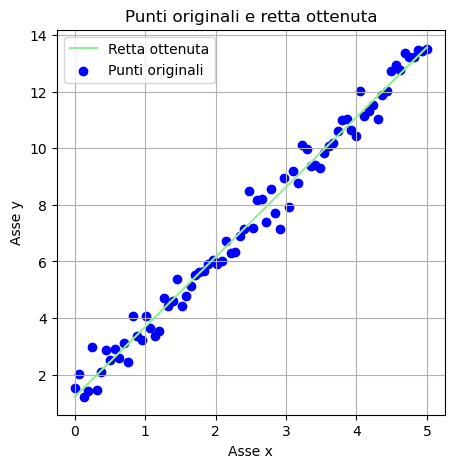

MAE: 0.35853394812444583, RMSE :0.4546130695975361


In [39]:
x = np.linspace(0, 5, 80)  
y = 2.5 * x + 1.2 + np.random.normal(0, 0.5, 80)
#1
def modello_retta(x, a, b):
    return a*x +b
parametri, cov = curve_fit(modello_retta, x, y)
a_pred, b_pred = parametri
y_pred = modello_retta(x, a_pred, b_pred)
#2
plt.figure(figsize=(5,5))
plt.plot(x, y_pred, color="lightgreen", label="Retta ottenuta")
plt.scatter(x, y, color="blue", label="Punti originali")
plt.title("Punti originali e retta ottenuta")
plt.xlabel("Asse x")
plt.ylabel("Asse y")
plt.legend()
plt.grid(True)
plt.show()
#3
mae = mean_absolute_error(y, y_pred)
rmse = root_mean_squared_error(y, y_pred)
print(f"MAE: {mae}, RMSE :{rmse}")